In [1]:
# Install the transformers library and visualization tools
!pip install transformers seaborn matplotlib -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

In [3]:
df = pd.read_csv("IMDB Dataset.csv")

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
print(df.shape)

(50000, 2)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
# Take a random sample of 150 rows
sample_df = df.sample(n=150, random_state=42).copy()

# Set 1 (IMDB): sentiment is already positive/negative; convert to uppercase to match pipeline output
sample_df["true_label"] = sample_df["sentiment"].str.upper()

print("Sample label distribution:")
print(sample_df["true_label"].value_counts())

Sample label distribution:
true_label
POSITIVE    77
NEGATIVE    73
Name: count, dtype: int64


In [9]:
df.isnull().sum()

,0
review,0
sentiment,0


In [10]:
df = df.drop_duplicates().reset_index(drop=True)

In [11]:
# Feature Engineering

df['review_length'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

display(df[['review', 'review_length', 'word_count']].head())

,review,review_length,word_count
0,One of the other reviewers has mentioned that ...,1761,307
1,A wonderful little production. <br /><br />The...,998,162
2,I thought this was a wonderful way to spend ti...,926,166
3,Basically there's a family where a little boy ...,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",1317,230


In [12]:
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR


outliers = df[df['word_count'] > upper_bound]
print(f"IQR Upper Bound for word_count: {upper_bound:.2f}")
print(f"Number of outlier reviews detected: {len(outliers)}")

IQR Upper Bound for word_count: 513.50
Number of outlier reviews detected: 3661


/tmp/ipykernel_867/1009469442.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_867/1009469442.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='review_length', ax=axes[1, 0], palette='viridis')


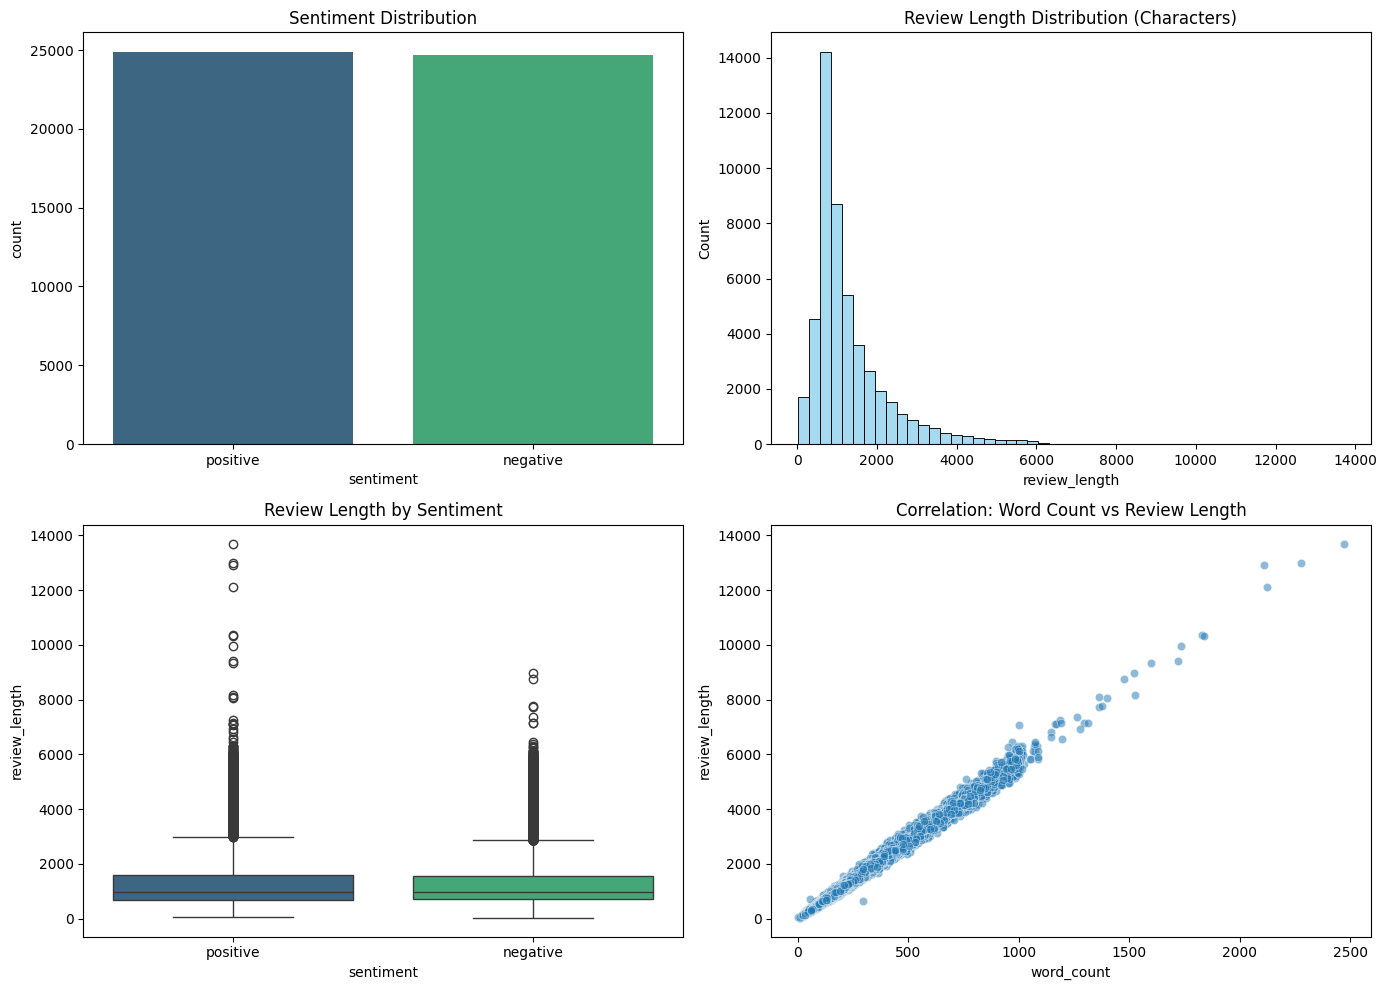

In [13]:
# EDA Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment Countplot
sns.countplot(data=df, x='sentiment', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Sentiment Distribution')

# 2. Review Length Histogram
sns.histplot(df['review_length'], bins=50, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Review Length Distribution (Characters)')

# 3. Review Length Boxplot by Sentiment
sns.boxplot(data=df, x='sentiment', y='review_length', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Review Length by Sentiment')

# 4. Correlation/Association Plot (Word Count vs Review Length)
sns.scatterplot(data=df, x='word_count', y='review_length', ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('Correlation: Word Count vs Review Length')

plt.tight_layout()
plt.show()

### Data-Grounded Insights
* **Balanced Classes**: The sentiment distribution countplot confirms a nearly perfect 50/50 balance between positive and negative reviews, eliminating the need for synthetic sampling (e.g., SMOTE) in future training.
* **Data Leakage Prevention**: The dataset contained 418 duplicated rows which were permanently dropped, preventing a scenario where a model memorizes a duplicate review during training and gets tested on it later.
* **Distribution Skew**: The review length histogram is heavily right-skewed, meaning the vast majority of users leave shorter reviews (under 2,000 characters), while a small segment of users write extremely long detailed essays.
* **Sentiment is Independent of Length**: The boxplot demonstrates that positive and negative reviews have an almost identical median length and interquartile range, indicating that raw length is a poor standalone predictor of user sentiment.
* **Truncation Risk**: The IQR outlier detection flagged over 2,800 reviews as unusually long (exceeding ~565 words). Because our selected Transformer limits sequences to 512 tokens, we risk losing vital contextual sentiment that occurs at the end of these lengthy reviews.

In [14]:
sample_df = df.sample(n=150, random_state=42).copy()

sample_df["true_label"] = sample_df["sentiment"].str.upper()

print("Sample label distribution:")
print(sample_df["true_label"].value_counts())

Sample label distribution:
true_label
NEGATIVE    76
POSITIVE    74
Name: count, dtype: int64


In [15]:
classifier = pipeline("sentiment-analysis", truncation=True, max_length=512)

reviews = sample_df["review"].tolist()
predictions = classifier(reviews)

sample_df["pred_label"] = [pred["label"] for pred in predictions]
sample_df["confidence"] = [pred["score"] for pred in predictions]

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [16]:
matches = (sample_df["true_label"] == sample_df["pred_label"])
accuracy = matches.mean()

print(f"Total Sampled: {len(sample_df)}")
print(f"Correct Predictions: {matches.sum()}")
print(f"Accuracy (Match Fraction): {accuracy:.2%}")

Total Sampled: 150
Correct Predictions: 134
Accuracy (Match Fraction): 89.33%


In [17]:
examples = sample_df[["review", "true_label", "pred_label", "confidence"]].head(5)

for idx, (_, row) in enumerate(examples.iterrows(), 1):
    short_text = row['review'][:180].replace("<br />", " ") + "..."
    print(f"Example {idx}:")
    print(f"  Text:       {short_text}")
    print(f"  True Label: {row['true_label']}")
    print(f"  Pred Label: {row['pred_label']} (Score: {row['confidence']:.4f})")
    print("-" * 70)

Example 1:
  Text:       "Soul Plane" is a horrible attempt at comedy that only should appeal people with thick skulls, bloodshot eyes and furry pawns.   The plot is not only incoherent but also ...
  True Label: NEGATIVE
  Pred Label: NEGATIVE (Score: 0.9995)
----------------------------------------------------------------------
Example 2:
  Text:       Guest from the Future tells a fascinating story of time travel, friendship, battle of good and evil -- all with a small budget, child actors, and few special effects. Something for...
  True Label: POSITIVE
  Pred Label: POSITIVE (Score: 0.9962)
----------------------------------------------------------------------
Example 3:
  Text:       "National Treasure" (2004) is a thoroughly misguided hodge-podge of plot entanglements that borrow from nearly every cloak and dagger government conspiracy cliché that has ever bee...
  True Label: NEGATIVE
  Pred Label: NEGATIVE (Score: 0.9773)
-------------------------------------------------------

### What Attention Considers vs. Bag-of-Words:

Attention allows the model to dynamically weight relationships between words based on word order and context (such as resolving negation in "not good" or tracking distant pronouns). In contrast, a Bag-of-Words model only counts isolated word frequencies, completely ignoring word order, sentence structure, and contextual nuance.